# XGBoost check: does cognition add *nonlinear* predictive value for symptoms?

The CCA ladder found only ~1% shared variance and no nonlinear/foundation-model arm beat the linear baseline; the Anna Karenina deviation test was similarly null. Those framings look for a *shared axis* or a *deviation-magnitude* signal. This is a direct predictive check for any nonlinearity they might miss.

For each survey score we compare two gradient-boosted tree models on held-out data:

* **null** — features = `age`, `sex`
* **full** — features = `age`, `sex` + the 30 cognitive task parameters

A tree recovers `age²` and `age×sex` from `age` and `sex` by splitting, so the arms differ **only** in whether the cognitive parameters are available. Gradient-boosted trees can capture nonlinear interactions among the 30 parameters that CCA/rCCA cannot, so no detected gain here is evidence against a nonlinear cognition→symptom signal *recoverable by this XGBoost pipeline on this sample* (one fixed depth-3 configuration, ~415 fitting rows per SHARP fold — not a model-agnostic proof of absence).

Inference uses the paper-faithful **SHARP null-constrained score test** (Zeng et al. 2026, S7.6/S7.8) on the paired per-half difference in held-out R² (full − null): a valid, fold-dependence-aware, one-sided (full > null) p with a test-inversion CI. Both arms use the identical algorithm (fixed shallow trees; rounds tuned by early stopping inside each training fold). The raw half-statistics are retained in the artifact.

**Training half only** (N=1298 after the `max_rhat>1.1` exclusion, matching the CCA run); the held-out half is never read.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
res = pl.read_parquet("../data/exploratory/xgb_nonlinear_results.parquet")
print(f"targets: {res.height} | N: {res['n'][0]} | J={res['J'][0]}, K={res['K'][0]}")

targets: 20 | N: 1298 | J=30, K=5


## 1. Per-target held-out R² gain (full − null), SHARP inference

`mean_r2_gain` is the SHARP D̄ (mean over halves/reps); `p_one_sided` tests full > null; `q_fdr` is BH-FDR across the 20 survey scores.

In [2]:
tbl = (res.select(['target', 'mean_r2_gain', 'ci_lo', 'ci_hi',
                   'p_one_sided', 'q_fdr', 'rho'])
          .with_columns([pl.col(c).round(4) for c in
                         ['mean_r2_gain', 'ci_lo', 'ci_hi', 'p_one_sided', 'q_fdr', 'rho']]))
print(tbl)
n_sig = int((res['q_fdr'] < 0.05).sum())
print(f"\nTargets surviving BH-FDR (q<0.05): {n_sig} / {res.height}")

shape: (20, 7)
┌─────────────────────┬──────────────┬─────────┬─────────┬─────────────┬────────┬────────┐
│ target              ┆ mean_r2_gain ┆ ci_lo   ┆ ci_hi   ┆ p_one_sided ┆ q_fdr  ┆ rho    │
│ ---                 ┆ ---          ┆ ---     ┆ ---     ┆ ---         ┆ ---    ┆ ---    │
│ str                 ┆ f64          ┆ f64     ┆ f64     ┆ f64         ┆ f64    ┆ f64    │
╞═════════════════════╪══════════════╪═════════╪═════════╪═════════════╪════════╪════════╡
│ hitop_hypsom        ┆ -0.0005      ┆ -0.0233 ┆ 0.0222  ┆ 0.5236      ┆ 0.9958 ┆ 0.2097 │
│ hitop_welbe         ┆ -0.0013      ┆ -0.0206 ┆ 0.018   ┆ 0.5671      ┆ 0.9958 ┆ 0.238  │
│ hitop               ┆ -0.0177      ┆ -0.0482 ┆ 0.0128  ┆ 0.899       ┆ 0.9958 ┆ 0.2821 │
│ hitop_appgn         ┆ -0.006       ┆ -0.0185 ┆ 0.0064  ┆ 0.9097      ┆ 0.9958 ┆ 0.0987 │
│ hitop_socanx        ┆ -0.0159      ┆ -0.0413 ┆ 0.0094  ┆ 0.9134      ┆ 0.9958 ┆ 0.2829 │
│ …                   ┆ …            ┆ …       ┆ …       ┆ …           ┆ … 

## 2. Held-out R² gain per survey score with SHARP 95% CI

Points right of 0 mean the cognitive parameters improved held-out prediction. Red = survives BH-FDR (q<0.05).

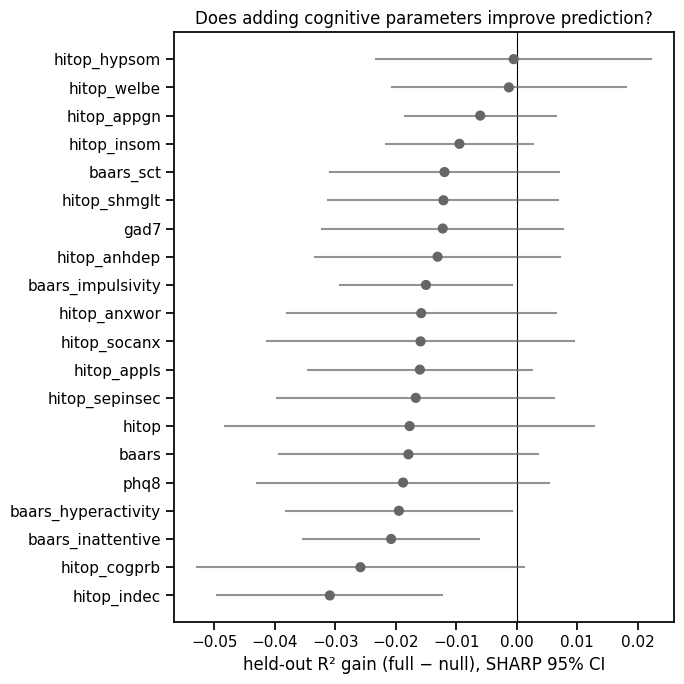

In [3]:
d = res.sort('mean_r2_gain')
targets = d['target'].to_list()
gain = d['mean_r2_gain'].to_numpy()
lo, hi = d['ci_lo'].to_numpy(), d['ci_hi'].to_numpy()
q = d['q_fdr'].to_numpy()
y = np.arange(len(targets))
colors = np.where(q < 0.05, 'crimson', '0.4')

fig, ax = plt.subplots(figsize=(7, 7))
ax.axvline(0, color='k', lw=0.8, zorder=0)
for i in range(len(targets)):
    ax.plot([lo[i], hi[i]], [y[i], y[i]], color=colors[i], lw=1.5, alpha=0.7)
ax.scatter(gain, y, c=colors, s=40, zorder=5)
ax.set_yticks(y); ax.set_yticklabels(targets)
ax.set_xlabel('held-out R² gain (full − null), SHARP 95% CI')
ax.set_title('Does adding cognitive parameters improve prediction?')
plt.tight_layout()
plt.show()

## 3. Cross-check: full-sample K-fold (no SHARP split-half)

SHARP splits each repetition into two disjoint halves, so each model trains on only ~415 rows here — a concern given the modest N. As a robustness check we repeat the same full-vs-null XGBoost contrast with **repeated stratified K-fold on the whole training-half sample** (each model trains on ~830 rows, roughly double), and simply compare the held-out R² directly. No split-half means the SHARP variance estimator does not apply, so this is purely descriptive — the question is whether more training data surfaces any *positive* R² gain. (Still training half only; the held-out half is never read.)

In [4]:
kf = pl.read_parquet("../data/exploratory/xgb_kfold_results.parquet")
kftbl = (kf.select(['target', 'mean_r2_gain', 'ci_lo', 'ci_hi',
                    'frac_folds_positive', 'max_fold_gain', 'mean_r2_full', 'mean_r2_null'])
           .with_columns([pl.col(c).round(4) for c in
                          ['mean_r2_gain', 'ci_lo', 'ci_hi', 'frac_folds_positive',
                           'max_fold_gain', 'mean_r2_full', 'mean_r2_null']]))
print(kftbl)
n_pos = int((kf['mean_r2_gain'] > 0).sum())
print(f"\nTargets with a positive mean R2 gain: {n_pos} / {kf.height}")
print(f"Largest mean R2 gain: {kf['mean_r2_gain'].max():+.4f} "
      f"({kf.sort('mean_r2_gain', descending=True)['target'][0]})")

shape: (20, 8)
┌─────────────┬─────────────┬─────────┬────────┬────────────┬────────────┬────────────┬────────────┐
│ target      ┆ mean_r2_gai ┆ ci_lo   ┆ ci_hi  ┆ frac_folds ┆ max_fold_g ┆ mean_r2_fu ┆ mean_r2_nu │
│ ---         ┆ n           ┆ ---     ┆ ---    ┆ _positive  ┆ ain        ┆ ll         ┆ ll         │
│ str         ┆ ---         ┆ f64     ┆ f64    ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│             ┆ f64         ┆         ┆        ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞═════════════╪═════════════╪═════════╪════════╪════════════╪════════════╪════════════╪════════════╡
│ hitop_welbe ┆ 0.0064      ┆ -0.0342 ┆ 0.0478 ┆ 0.64       ┆ 0.0856     ┆ 0.0026     ┆ -0.0038    │
│ hitop_hypso ┆ 0.0041      ┆ -0.0451 ┆ 0.038  ┆ 0.68       ┆ 0.047      ┆ 0.0064     ┆ 0.0023     │
│ m           ┆             ┆         ┆        ┆            ┆            ┆            ┆            │
│ gad7        ┆ 0.0004      ┆ -0.0685 ┆ 0.0513 ┆ 0.57       ┆ 0.0839     ┆ 0

The gaps shrink toward zero relative to the split-half test (the extra features needed more data to stop hurting), and a few targets tip marginally positive — but the fold-level 95% bands all straddle zero, the fractions of positive folds sit near a coin-flip, and the full-model absolute R² for the 'positive' targets is ~0. More data does not surface a real nonlinear cognition→symptom signal.

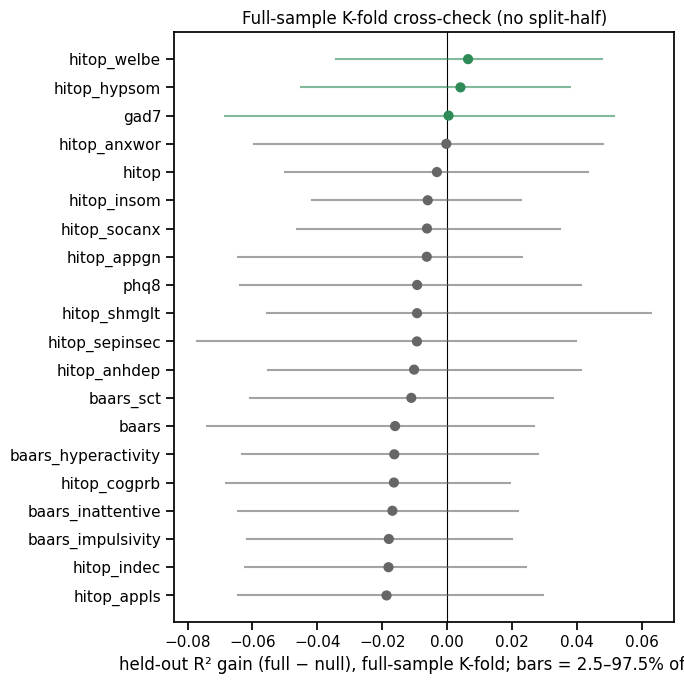

In [5]:
d = kf.sort('mean_r2_gain')
targets = d['target'].to_list()
gain = d['mean_r2_gain'].to_numpy()
lo, hi = d['ci_lo'].to_numpy(), d['ci_hi'].to_numpy()
y = np.arange(len(targets))
colors = np.where(gain > 0, 'seagreen', '0.4')

fig, ax = plt.subplots(figsize=(7, 7))
ax.axvline(0, color='k', lw=0.8, zorder=0)
for i in range(len(targets)):
    ax.plot([lo[i], hi[i]], [y[i], y[i]], color=colors[i], lw=1.5, alpha=0.6)
ax.scatter(gain, y, c=colors, s=40, zorder=5)
ax.set_yticks(y); ax.set_yticklabels(targets)
ax.set_xlabel('held-out R² gain (full − null), full-sample K-fold; bars = 2.5–97.5% of folds')
ax.set_title('Full-sample K-fold cross-check (no split-half)')
plt.tight_layout()
plt.show()

## 4. Feature view: the 4 per-task summary scores (SHARP)

The 30 fitted parameters are a high-dimensional, noisy view of task behavior. As a lower-dimensional alternative we repeat the SHARP full-vs-null test with the full model's cognitive features set to the **4 per-task summary scores** (`{task}__sub_score`) instead of the 30 parameters — everything else identical (same N=1298, same age+sex null, same one-sided SHARP). If a coarse behavioral summary carried symptom signal that the parameters diluted, it would show here.

In [6]:
ss = pl.read_parquet("../data/exploratory/xgb_subscores_sharp_results.parquet")
sstbl = (ss.select(['target', 'mean_r2_gain', 'ci_lo', 'ci_hi', 'p_one_sided', 'q_fdr'])
           .with_columns([pl.col(c).round(4) for c in
                          ['mean_r2_gain', 'ci_lo', 'ci_hi', 'p_one_sided', 'q_fdr']]))
print(sstbl)
n_sig = int((ss['q_fdr'] < 0.05).sum())
n_pos = int((ss['mean_r2_gain'] > 0).sum())
print(f"\nPositive mean R2 gain: {n_pos}/{ss.height} | surviving BH-FDR (q<0.05): {n_sig}/{ss.height}")

shape: (20, 6)
┌─────────────────────┬──────────────┬─────────┬─────────┬─────────────┬────────┐
│ target              ┆ mean_r2_gain ┆ ci_lo   ┆ ci_hi   ┆ p_one_sided ┆ q_fdr  │
│ ---                 ┆ ---          ┆ ---     ┆ ---     ┆ ---         ┆ ---    │
│ str                 ┆ f64          ┆ f64     ┆ f64     ┆ f64         ┆ f64    │
╞═════════════════════╪══════════════╪═════════╪═════════╪═════════════╪════════╡
│ hitop_welbe         ┆ 0.0002       ┆ -0.0135 ┆ 0.0139  ┆ 0.1581      ┆ 0.9966 │
│ hitop_hypsom        ┆ -0.0022      ┆ -0.0173 ┆ 0.0129  ┆ 0.7611      ┆ 0.9966 │
│ hitop_shmglt        ┆ -0.0073      ┆ -0.0285 ┆ 0.0139  ┆ 0.7901      ┆ 0.9966 │
│ baars_sct           ┆ -0.0092      ┆ -0.0324 ┆ 0.014   ┆ 0.8508      ┆ 0.9966 │
│ hitop_appls         ┆ -0.0021      ┆ -0.0174 ┆ 0.0132  ┆ 0.8514      ┆ 0.9966 │
│ …                   ┆ …            ┆ …       ┆ …       ┆ …           ┆ …      │
│ baars_hyperactivity ┆ -0.0158      ┆ -0.0304 ┆ -0.0012 ┆ 0.9794      ┆ 0.9966 │
│

Same null. 19/20 targets negative, only `hitop_welbe` a hair positive (+0.0002, one-sided score-test p≈0.16); no target survives FDR. Fewer, cleaner features make the gaps slightly less negative and the SHARP CIs tighter, but nothing crosses into a real positive gain. The result is robust across feature representations (30 parameters vs 4 summary scores) as well as evaluation schemes (SHARP split-half vs full-sample K-fold).

## Conclusion

**No incremental predictive gain detected.** For (nearly) every survey score the held-out R² gain from adding the cognitive parameters is ≤ 0 — the full model does not out-predict the age+sex baseline — and **no target survives BH-FDR** under the one-sided SHARP score test. The closest-to-zero targets (`hitop_hypsom`, `hitop_welbe`) are still non-significant.

The justified claim is deliberately narrow: *no incremental predictive gain for these features (the 30 fitted parameters) with this XGBoost pipeline (fixed depth-3, ~415 fitting rows per SHARP fold) on this training-half sample* — **not** a model-agnostic proof that no nonlinear cognition→symptom relationship exists. Within that scope it corroborates the CCA-ladder and Anna Karenina nulls.

Two robustness checks agree: the full-sample K-fold cross-check (§3, ~830 rows/fold, no split-half) only shrinks the gaps toward zero (a few tip marginally positive, none distinguishable from noise), and swapping the 30 parameters for the 4 per-task summary scores (§4) gives the same null. The result holds across these feature representations and evaluation schemes.

_Training half only; the held-out half remains untouched for any future confirmatory step._